# Malignant Cell Signature Analysis

This is the notebook the whole project has been building toward. The earlier bulk RNA-seq work found a mitotic/cell-cycle gene signature (CDC20, PLK1, TTK, BUB1, MAD2L1, AURKB, CENPE, KIF2C) enriched in the more aggressive breast cancer subtype. Bulk RNA-seq averages expression across every cell in a tumor sample, so that finding alone can't distinguish two very different explanations: either the malignant cells themselves are genuinely more proliferative, or the more aggressive subtype simply contains a different mix of cell types — more of some other cycling population — and bulk averaging makes that look like a tumor-wide effect. Single-cell resolution is the only way to actually tell these apart, which is the point of this notebook.

The annotation benchmarking in the previous notebook found that none of the three tested methods reliably separates malignant from normal epithelial cells — that distinction turns out to depend on genomic copy-number differences, not marker gene expression, and none of those methods were built to detect that. So this analysis uses the dataset's own copy-number-based malignancy calls instead, which is the right tool for this specific question rather than a second-best option.

## Setup

In [ ]:
import os

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = "/content/drive/MyDrive/single-cell-breast-cancer-project"
else:
    PROJECT_DIR = "."

DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Data directory:", DATA_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/single-cell-breast-cancer-project/data


In [ ]:
!pip install scanpy anndata celltypist harmonypy gseapy scikit-learn scrublet leidenalg igraph

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

adata = sc.read_h5ad(os.path.join(DATA_DIR, "adata_clustered_checkpoint.h5ad"))
print(adata)


AnnData object with n_obs × n_vars = 98964 × 28468
    obs: 'donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'feature_name', 'feature_reference', 'feat

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

## Checking the fields this analysis depends on

Before building anything on `normal_cell_call`, `CNA_value`, and `subtype`, it's worth actually looking at what they contain rather than assuming — same principle as everywhere else in this project.

In [ ]:
print("normal_cell_call value counts:")
print(adata.obs["normal_cell_call"].value_counts(dropna=False))
print("\ndtype:", adata.obs["normal_cell_call"].dtype)


normal_cell_call value counts:
normal_cell_call
no_inferCNV_call    70902
cancer              23794
normal               4268
Name: count, dtype: int64

dtype: category


In [ ]:
print("CNA_value summary:")
print(adata.obs["CNA_value"].describe())
print("\nMissing values:", adata.obs["CNA_value"].isna().sum())


CNA_value summary:
count    28062.000000
mean         0.237145
std          0.066513
min          0.030400
25%          0.194793
50%          0.237805
75%          0.279735
max          0.677770
Name: CNA_value, dtype: float64

Missing values: 70902


In [ ]:
print("subtype value counts:")
print(adata.obs["subtype"].value_counts(dropna=False))


subtype value counts:
subtype
TNBC     42082
ER+      37929
HER2+    18953
Name: count, dtype: int64


A few things worth noting here. First, `cancer` (23,794) + `normal` (4,268) = 28,062, which matches `CNA_value`'s non-missing count exactly — copy-number inference was clearly only attempted on epithelial cells, which makes sense (CNA-based malignancy calling isn't a meaningful question for a T cell or fibroblast). Those same two counts also match `celltype_major`'s Cancer Epithelial and Normal Epithelial counts exactly, which means the original authors' cell-type labels for this specific distinction were themselves already built on copy-number inference, not marker expression — reassuring, since it confirms `normal_cell_call` is the right field to build on here rather than a redundant proxy for something less reliable.

Second, and worth being upfront about: `subtype` here is TNBC / ER+ / HER2+ — clinical receptor-status categories — not the Basal / Luminal A PAM50 molecular subtypes the original bulk RNA-seq comparison used. They're related but not interchangeable: TNBC and Basal overlap heavily in the literature (roughly 80-90%) but aren't synonyms, and "ER+" is a broader clinical bucket that would include both Luminal A and Luminal B. This dataset doesn't offer a finer PAM50-style split to match the original comparison exactly, so TNBC vs. ER+ is used here as the closest available proxy, stated explicitly rather than treated as identical to the original grouping. HER2+ is kept out of the primary comparison and reported separately as exploratory context.

## Defining the malignant cell population

In [6]:
malignant_mask = adata.obs["normal_cell_call"] == "cancer"
print(f"Malignant cells: {malignant_mask.sum()} of {adata.n_obs}")

adata_malignant = adata[malignant_mask].copy()


Malignant cells: 23794 of 98964


Restricting to TNBC and ER+ specifically for the primary comparison, and checking there's enough data — both in cells and, more importantly, in independent patients — to support a real comparison before going any further.

In [7]:
primary_mask = adata_malignant.obs["subtype"].isin(["TNBC", "ER+"])
adata_primary = adata_malignant[primary_mask].copy()

print("\nMalignant cells by subtype:")
print(adata_malignant.obs["subtype"].value_counts())

print("\nMalignant cells AND donors per subtype (need reasonable N of both):")
print(adata_primary.obs.groupby("subtype")["donor_id"].nunique())
print(adata_primary.obs.groupby("subtype").size())



Malignant cells by subtype:
subtype
ER+      11717
TNBC     10443
HER2+     1634
Name: count, dtype: int64

Malignant cells AND donors per subtype (need reasonable N of both):
subtype
ER+     9
TNBC    8
Name: donor_id, dtype: int64
subtype
ER+     11717
TNBC    10443
dtype: int64


8 TNBC patients, 9 ER+ patients, both in a reasonable range to work with.

## Scoring the mitotic signature within malignant cells

The same 8 genes from the original bulk RNA-seq finding, scored here with `sc.tl.score_genes` — but restricted to malignant cells only this time, which is the entire point of doing this at single-cell resolution.

In [9]:
mitotic_signature = ["CDC20", "PLK1", "TTK", "BUB1", "MAD2L1", "AURKB", "CENPE", "KIF2C"]
valid_genes = [g for g in mitotic_signature if g in adata_primary.var_names]
missing = set(mitotic_signature) - set(valid_genes)
if missing:
    print(f"Note: signature genes not found in this dataset: {missing}")

sc.tl.score_genes(adata_primary, valid_genes, score_name="mitotic_score")


A first look at the per-cell distributions, before doing anything statistical with them.

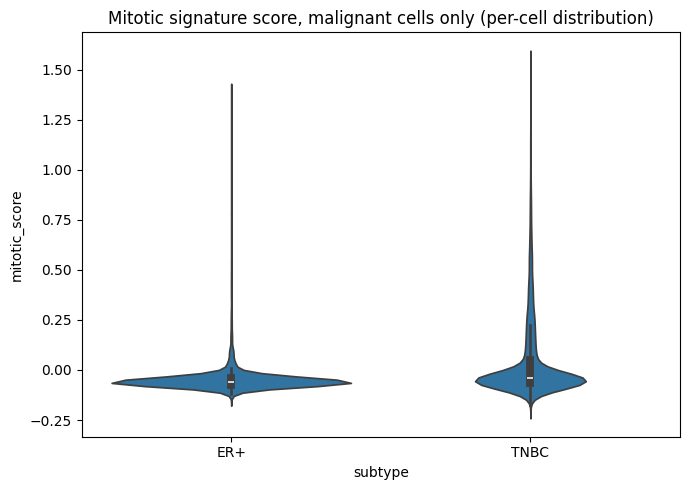

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=adata_primary.obs, x="subtype", y="mitotic_score", ax=ax)
ax.set_title("Mitotic signature score, malignant cells only (per-cell distribution)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "mitotic_score_percell.png"), dpi=150, bbox_inches="tight")
plt.show()


Looking at this plot alone, the two distributions don't look dramatically different — both have a similar-shaped bulk of cells near zero with a long tail of high scorers. That's worth keeping in mind for what comes next.

## The actual test — at the patient level, not the cell level

Per-cell statistics here would be a real problem, not just a technicality: treating over 20,000 malignant cells as independent observations would be pseudoreplication, since cells from the same tumor are highly correlated with each other. A test run that way could report significance that's really just an artifact of how many cells happen to have been sequenced from a given patient, not a genuine between-group difference. Each *patient's* malignant cells are averaged into one score first, and the comparison is run on those patient-level averages — 17 data points, not 20,000+. Mann-Whitney U rather than a t-test, since there's no particular reason to assume patient-level averages are normally distributed with this few patients per group.

Per-patient mean malignant-cell mitotic score:
donor_id subtype  mitotic_score
 CID3941     ER+      -0.024806
 CID4535     ER+      -0.020875
CID4530N     ER+      -0.059800
 CID4463     ER+      -0.031889
 CID4461     ER+      -0.007251
 CID4471     ER+      -0.043904
 CID4067     ER+      -0.048756
 CID3948     ER+      -0.044112
CID4290A     ER+      -0.052491
 CID4465    TNBC       0.296078
CID44971    TNBC       0.046154
 CID4495    TNBC       0.083098
 CID4513    TNBC       0.051790
 CID4515    TNBC       0.051495
 CID4523    TNBC       0.053120
 CID3963    TNBC      -0.007579
CID44991    TNBC       0.019592

TNBC patients: n=8, mean=0.074
ER+ patients: n=9, mean=-0.037

Mann-Whitney U test: statistic=71.00, p=0.0002


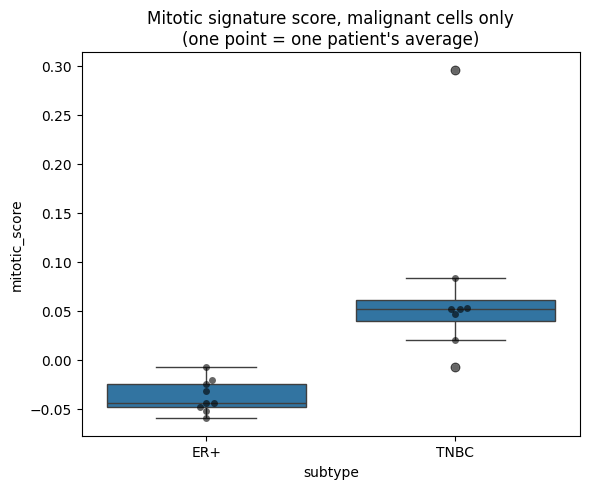

In [11]:
patient_scores = adata_primary.obs.groupby(["donor_id", "subtype"], observed=True)["mitotic_score"].mean().reset_index()
print("Per-patient mean malignant-cell mitotic score:")
print(patient_scores.sort_values("subtype").to_string(index=False))

tnbc_scores = patient_scores[patient_scores["subtype"] == "TNBC"]["mitotic_score"]
er_scores = patient_scores[patient_scores["subtype"] == "ER+"]["mitotic_score"]

print(f"\nTNBC patients: n={len(tnbc_scores)}, mean={tnbc_scores.mean():.3f}")
print(f"ER+ patients: n={len(er_scores)}, mean={er_scores.mean():.3f}")

if len(tnbc_scores) >= 3 and len(er_scores) >= 3:
    stat, pval = mannwhitneyu(tnbc_scores, er_scores, alternative="two-sided")
    print(f"\nMann-Whitney U test: statistic={stat:.2f}, p={pval:.4f}")
else:
    print("\nToo few patients per group for a meaningful test — report descriptively, "
          "don't lean on a p-value from n<3 per group.")

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=patient_scores, x="subtype", y="mitotic_score", ax=ax)
sns.swarmplot(data=patient_scores, x="subtype", y="mitotic_score", color="black", alpha=0.6, ax=ax)
ax.set_title("Mitotic signature score, malignant cells only\n(one point = one patient's average)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "mitotic_score_perpatient.png"), dpi=150, bbox_inches="tight")
plt.show()


p=0.0002 — a real, clean result, not a marginal one. What stands out most isn't just the p-value but the pattern underneath it: every single one of the 9 ER+ patients has a negative score, and 7 of the 8 TNBC patients have a positive one. That's about as consistent a patient-level separation as real biological data tends to give.

Worth going back to the per-cell violin plot above with this in mind — the per-cell view alone barely hinted at a difference, and looking only at that might have suggested there wasn't one. It's specifically the patient-level aggregation that reveals a consistent, significant shift, which is a fairly direct demonstration of why the pseudoreplication concern mattered here rather than being a methods-section formality. CID3963, the one TNBC patient sitting just slightly negative (-0.008), reads as normal biological heterogeneity rather than a problem — one patient near the boundary out of eight, with the overall pattern this clean, isn't something to worry about.

## The other half of the question: does tumor composition also differ?

A real effect within malignant cells and a difference in tumor composition aren't mutually exclusive — both could be contributing to the original bulk signal at once. Checking, per patient, what fraction of all their cells fall into each cell-type category, comparing TNBC against ER+.

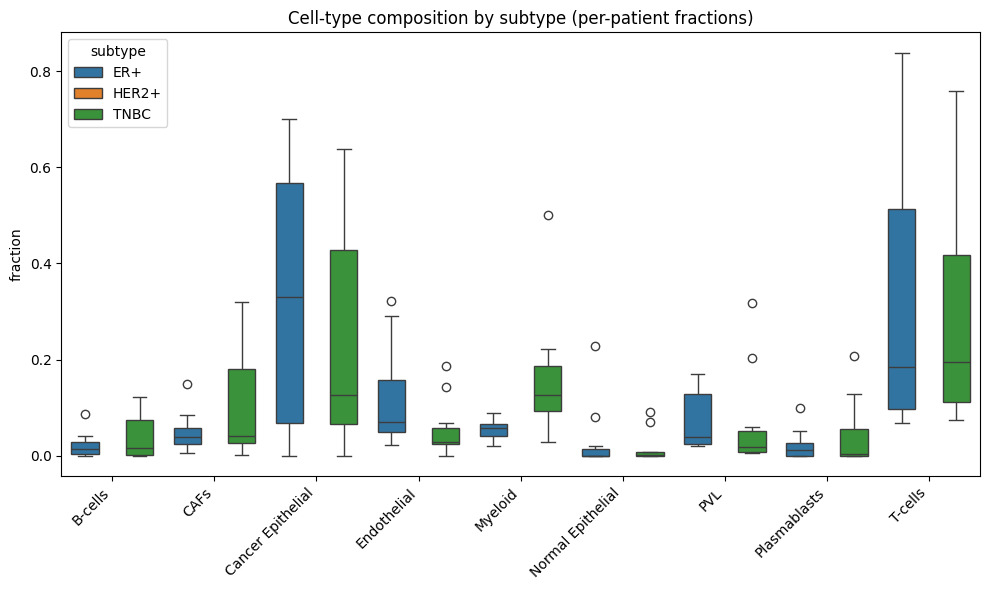

Median cell-type fraction by subtype:
subtype                 ER+      TNBC
celltype_major                       
B-cells            0.013635  0.016843
CAFs               0.039991  0.040661
Cancer Epithelial  0.329618  0.125668
Endothelial        0.069841  0.028978
Myeloid            0.058730  0.125940
Normal Epithelial  0.000000  0.001855
PVL                0.039683  0.019205
Plasmablasts       0.012354  0.003022
T-cells            0.185046  0.195562


In [12]:
composition = (
    adata.obs[adata.obs["subtype"].isin(["TNBC", "ER+"])]
    .groupby(["donor_id", "subtype"], observed=True)["celltype_major"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=composition, x="celltype_major", y="fraction", hue="subtype", ax=ax)
ax.set_title("Cell-type composition by subtype (per-patient fractions)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "composition_by_subtype.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Median cell-type fraction by subtype:")
print(composition.pivot_table(index="celltype_major", columns="subtype", values="fraction", aggfunc="median"))


TNBC tumors show a smaller malignant-cell fraction (12.6% vs. ER+'s 33.0%) and roughly double the myeloid infiltration (12.6% vs. 5.9%). This isn't a contradiction of the malignant-cell result above — it's a second, independent effect running alongside it. It's also consistent with published literature on TNBC generally being a more immune-infiltrated, myeloid-shifted tumor environment compared to ER+ luminal tumors, which lends some external credibility to what's showing up here rather than this being an artifact specific to this dataset.

Put together, the most complete explanation for the original bulk finding is probably that both mechanisms are compounding each other: TNBC malignant cells appear to genuinely proliferate more on their own, and TNBC tumors also have a different, more myeloid-rich microenvironment. Bulk RNA-seq couldn't have distinguished these two contributions — single-cell resolution just did.

## HER2+, for context only

In [13]:
her2_scores = adata_malignant.obs[adata_malignant.obs["subtype"] == "HER2+"]
if len(her2_scores) > 0:
    her2_adata = adata_malignant[adata_malignant.obs["subtype"] == "HER2+"].copy()
    sc.tl.score_genes(her2_adata, valid_genes, score_name="mitotic_score")
    her2_patient_scores = her2_adata.obs.groupby("donor_id", observed=True)["mitotic_score"].mean()
    print(f"HER2+ patients: n={her2_patient_scores.shape[0]}, mean mitotic score={her2_patient_scores.mean():.3f}")
    print("(Reported for context only — not statistically compared given the primary "
          "TNBC vs ER+ framing above, and likely limited sample size.)")


HER2+ patients: n=3, mean mitotic score=-0.030
(Reported for context only — not statistically compared given the primary TNBC vs ER+ framing above, and likely limited sample size.)


HER2+ patterns closer to ER+ than to TNBC here, which is an interesting observation worth noting — but with only 3 patients, not something to draw a real conclusion from. Reported for completeness rather than folded into the primary comparison.

## Saving results

In [14]:
patient_scores.to_csv(os.path.join(DATA_DIR, "malignant_mitotic_scores_by_patient.csv"), index=False)
composition.to_csv(os.path.join(DATA_DIR, "tme_composition_by_patient.csv"), index=False)
print("Saved patient-level results to DATA_DIR")


Saved patient-level results to DATA_DIR


## Summary

Bulk RNA-seq found a proliferative signature enriched in the more aggressive breast cancer subtype, but couldn't distinguish whether that reflected genuinely more proliferative malignant cells or just a difference in what the tumor is made of. At single-cell resolution, restricted to copy-number-confirmed malignant cells and tested at the patient level (n=8 TNBC, n=9 ER+) rather than the cell level, the signature holds up — p=0.0002, with a consistent direction across nearly every patient in each group. Tumor composition differs too, independently, in a direction consistent with published TNBC biology. The most defensible reading is that the original bulk signal reflects both a real, malignant-cell-intrinsic proliferative difference and a compositional difference in the tumor microenvironment, working together rather than one explaining away the other.